# Formula 1 – Python deo seminarskog rada

Tema: predikcija da li vozač završava sezonu u Top 3 plasmanu. Kod koristi nazive promenljivih na srpskom bez dijakritike zbog kompatibilnosti.

## Formula 1 - Python deo seminarskog rada

In [ ]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

In [21]:
# 1. Podesavanja

In [22]:
PUTANJA = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
FOLDER_SLIKE = os.path.join(PUTANJA, "slike_python")
os.makedirs(FOLDER_SLIKE, exist_ok=True)

FAJL_VOZACI = os.path.join(PUTANJA, "drivers_updated.csv")
FAJL_POBEDNICI = os.path.join(PUTANJA, "winners.csv")
FAJL_NAJBRZI_KRUGOVI = os.path.join(PUTANJA, "fastest_laps_updated.csv")
FAJL_TIMOVI = os.path.join(PUTANJA, "teams_updated.csv")


def ocisti_tekst(vrednost):
    """Uklanja visestruke razmake i praznine oko teksta."""
    if pd.isna(vrednost):
        return vrednost
    return re.sub(r"\s+", " ", str(vrednost)).strip()


def sacuvaj_sliku(naziv_fajla):
    """Cuva aktivni matplotlib grafikon u folder slike_python."""
    putanja = os.path.join(FOLDER_SLIKE, naziv_fajla)
    plt.tight_layout()
    plt.savefig(putanja, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Slika sacuvana: {putanja}")

In [23]:
# 2. Ucitavanje podataka

In [24]:
vozaci = pd.read_csv(FAJL_VOZACI)
pobednici = pd.read_csv(FAJL_POBEDNICI)
najbrzi_krugovi = pd.read_csv(FAJL_NAJBRZI_KRUGOVI)
timovi = pd.read_csv(FAJL_TIMOVI)

print("Dimenzije skupova podataka:")
print("drivers_updated.csv:", vozaci.shape)
print("winners.csv:", pobednici.shape)
print("fastest_laps_updated.csv:", najbrzi_krugovi.shape)
print("teams_updated.csv:", timovi.shape)

print("\nNedostajuce vrednosti:")
print("Vozaci:\n", vozaci.isna().sum())
print("Pobednici:\n", pobednici.isna().sum())
print("Najbrzi krugovi:\n", najbrzi_krugovi.isna().sum())
print("Timovi:\n", timovi.isna().sum())

Dimenzije skupova podataka:
drivers_updated.csv: (1661, 7)
winners.csv: (1110, 7)
fastest_laps_updated.csv: (1108, 6)
teams_updated.csv: (695, 4)

Nedostajuce vrednosti:
Vozaci:
 Pos             0
Driver          0
Nationality     0
Car            11
PTS             0
year            0
Code            0
dtype: int64
Pobednici:
 Grand Prix    0
Date          0
Winner        0
Car           0
Laps          3
Time          3
Name Code     0
dtype: int64
Najbrzi krugovi:
 Grand Prix    0
Driver        0
Car           0
Time          1
year          0
Code          0
dtype: int64
Timovi:
 Pos     0
Team    0
PTS     0
year    0
dtype: int64


In [25]:
# 3. Predobrada podataka

In [26]:
vozaci["NazivVozaca"] = vozaci["Driver"].apply(ocisti_tekst)
vozaci["Nacionalnost"] = vozaci["Nationality"].apply(ocisti_tekst)
vozaci["Tim"] = vozaci["Car"].fillna("Nepoznato").apply(ocisti_tekst)
vozaci["Godina"] = vozaci["year"].astype(int)
vozaci["Decenija"] = ((vozaci["Godina"] // 10) * 10).astype(str) + "-e"
vozaci["PozicijaVozaca"] = pd.to_numeric(vozaci["Pos"], errors="coerce")

# Ciljna promenljiva: 1 ako je vozac zavrsio sezonu u Top 3, inace 0
vozaci["Top3Plasman"] = (vozaci["PozicijaVozaca"] <= 3).astype(int)

# Agregiranje broja pobeda po vozacu i sezoni
pobednici["NazivVozaca"] = pobednici["Winner"].apply(ocisti_tekst)
pobednici["Godina"] = pd.to_datetime(pobednici["Date"], errors="coerce").dt.year

broj_pobeda = (
    pobednici
    .groupby(["Godina", "NazivVozaca"])
    .size()
    .reset_index(name="BrojPobeda")
)

# Agregiranje broja najbrzih krugova po vozacu i sezoni
najbrzi_krugovi["NazivVozaca"] = najbrzi_krugovi["Driver"].apply(ocisti_tekst)
najbrzi_krugovi["Godina"] = najbrzi_krugovi["year"].astype(int)

broj_najbrzih_krugova = (
    najbrzi_krugovi
    .groupby(["Godina", "NazivVozaca"])
    .size()
    .reset_index(name="BrojNajbrzihKrugova")
)

# Spajanje podataka u jedan skup za modelovanje
podaci = vozaci.merge(
    broj_pobeda,
    on=["Godina", "NazivVozaca"],
    how="left"
)

podaci = podaci.merge(
    broj_najbrzih_krugova,
    on=["Godina", "NazivVozaca"],
    how="left"
)

podaci["BrojPobeda"] = podaci["BrojPobeda"].fillna(0).astype(int)
podaci["BrojNajbrzihKrugova"] = podaci["BrojNajbrzihKrugova"].fillna(0).astype(int)

# Za model ne koristimo PozicijaVozaca i PTS/BodoviVozaca kao ulazne atribute,
# jer bi oni direktno otkrivali konacan plasman.
atributi = [
    "Godina",
    "Decenija",
    "Nacionalnost",
    "Tim",
    "BrojPobeda",
    "BrojNajbrzihKrugova",
]
cilj = "Top3Plasman"

podaci_model = podaci[atributi + [cilj]].dropna().copy()

print("\nPrvih 10 redova skupa za modelovanje:")
print(podaci_model.head(10))

print("\nRaspodela ciljne promenljive:")
print(podaci_model[cilj].value_counts())


Prvih 10 redova skupa za modelovanje:
   Godina Decenija Nacionalnost                       Tim  BrojPobeda  \
0    1950   1950-e          ITA                Alfa Romeo           3   
1    1950   1950-e          ARG                Alfa Romeo           3   
2    1950   1950-e          ITA                Alfa Romeo           0   
3    1950   1950-e          FRA               Talbot-Lago           0   
4    1950   1950-e          ITA                   Ferrari           0   
5    1950   1950-e          USA  Kurtis Kraft Offenhauser           1   
6    1950   1950-e          USA         Deidt Offenhauser           0   
7    1950   1950-e          THA                  Maserati           0   
8    1950   1950-e          GBR                  Maserati           0   
9    1950   1950-e          MON                  Maserati           0   

   BrojNajbrzihKrugova  Top3Plasman  
0                    3            1  
1                    3            1  
2                    0            1  
3    

In [27]:
# 4. EDA vizualizacije

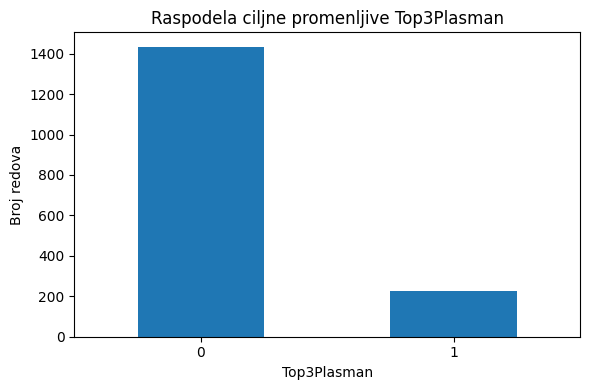

Slika sacuvana: c:\Users\Ilija\Desktop\F1_seminarski\python_deo\slike_python\01_raspodela_ciljne_promenljive.png


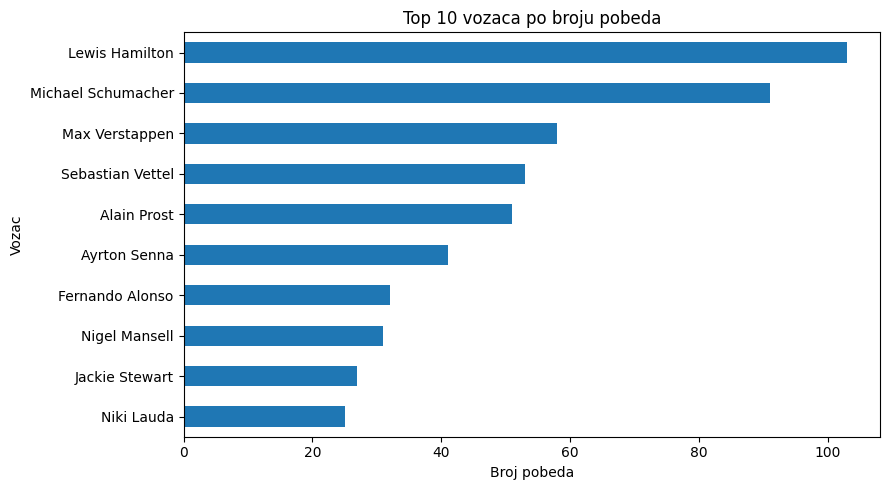

Slika sacuvana: c:\Users\Ilija\Desktop\F1_seminarski\python_deo\slike_python\02_top10_vozaci_pobede.png


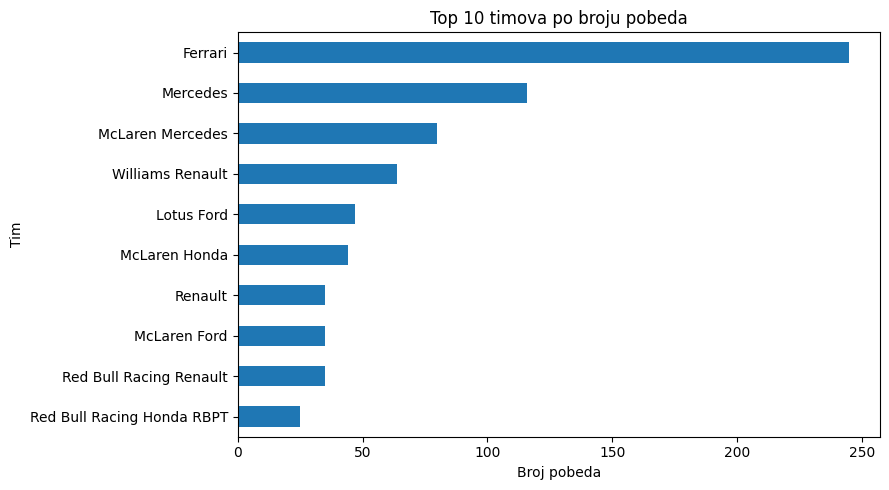

Slika sacuvana: c:\Users\Ilija\Desktop\F1_seminarski\python_deo\slike_python\03_top10_timovi_pobede.png


In [28]:
plt.figure(figsize=(6, 4))
podaci_model[cilj].value_counts().sort_index().plot(kind="bar")
plt.title("Raspodela ciljne promenljive Top3Plasman")
plt.xlabel("Top3Plasman")
plt.ylabel("Broj redova")
plt.xticks(rotation=0)
sacuvaj_sliku("01_raspodela_ciljne_promenljive.png")

top_vozaci = (
    podaci.groupby("NazivVozaca")["BrojPobeda"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
top_vozaci.sort_values().plot(kind="barh")
plt.title("Top 10 vozaca po broju pobeda")
plt.xlabel("Broj pobeda")
plt.ylabel("Vozac")
sacuvaj_sliku("02_top10_vozaci_pobede.png")

top_timovi = (
    pobednici.assign(Tim=pobednici["Car"].apply(ocisti_tekst))
    .groupby("Tim")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
top_timovi.sort_values().plot(kind="barh")
plt.title("Top 10 timova po broju pobeda")
plt.xlabel("Broj pobeda")
plt.ylabel("Tim")
sacuvaj_sliku("03_top10_timovi_pobede.png")

In [29]:
# 5. Podela na trening i test skup

In [30]:
X = podaci_model[atributi]
y = podaci_model[cilj]

numericki_atributi = ["Godina", "BrojPobeda", "BrojNajbrzihKrugova"]
kategoricki_atributi = ["Decenija", "Nacionalnost", "Tim"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [31]:
# 6. Modeli

In [32]:
preprocesiranje_logisticka = ColumnTransformer(
    transformers=[
        ("numericki", StandardScaler(), numericki_atributi),
        ("kategoricki", OneHotEncoder(handle_unknown="ignore"), kategoricki_atributi),
    ]
)

preprocesiranje_suma = ColumnTransformer(
    transformers=[
        ("numericki", "passthrough", numericki_atributi),
        ("kategoricki", OneHotEncoder(handle_unknown="ignore"), kategoricki_atributi),
    ]
)

modeli = {
    "Logisticka regresija": Pipeline(
        steps=[
            ("preprocesiranje", preprocesiranje_logisticka),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocesiranje", preprocesiranje_suma),
            ("model", RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                random_state=42,
                class_weight="balanced"
            )),
        ]
    ),
}

In [33]:
# 7. Treniranje i evaluacija


Logisticka regresija
              precision    recall  f1-score   support

  Nije Top 3       0.97      0.95      0.96       287
       Top 3       0.72      0.83      0.77        46

    accuracy                           0.93       333
   macro avg       0.84      0.89      0.86       333
weighted avg       0.94      0.93      0.93       333



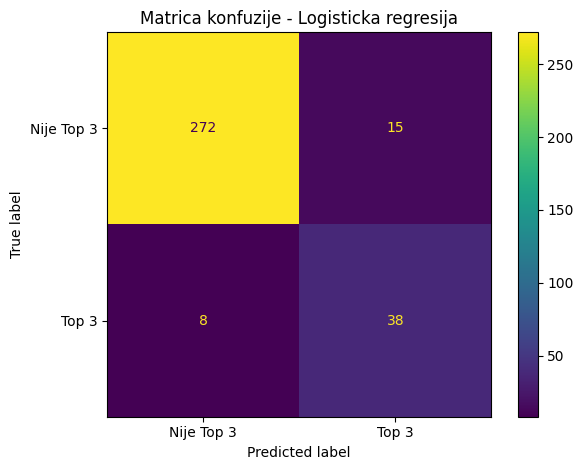

Slika sacuvana: c:\Users\Ilija\Desktop\F1_seminarski\python_deo\slike_python\04_matrica_konfuzije_logisticka_regresija.png

Random Forest
              precision    recall  f1-score   support

  Nije Top 3       0.97      0.90      0.93       287
       Top 3       0.57      0.85      0.68        46

    accuracy                           0.89       333
   macro avg       0.77      0.87      0.81       333
weighted avg       0.92      0.89      0.90       333



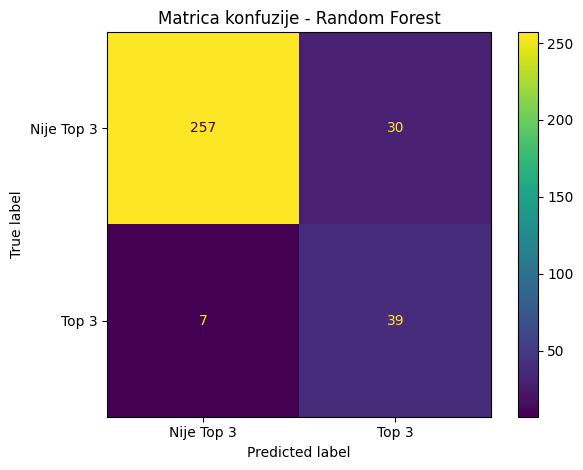

Slika sacuvana: c:\Users\Ilija\Desktop\F1_seminarski\python_deo\slike_python\04_matrica_konfuzije_random_forest.png

Tabela rezultata:
                  Model  Accuracy  Precision    Recall        F1
0  Logisticka regresija  0.930931   0.716981  0.826087  0.767677
1         Random Forest  0.888889   0.565217  0.847826  0.678261


<Figure size 800x500 with 0 Axes>

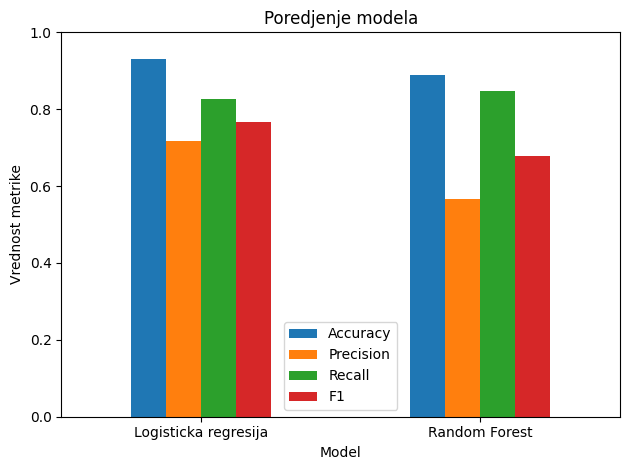

Slika sacuvana: c:\Users\Ilija\Desktop\F1_seminarski\python_deo\slike_python\05_poredjenje_modela.png


In [34]:
rezultati = []

for naziv_modela, model in modeli.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    tacnost = accuracy_score(y_test, y_pred)
    preciznost = precision_score(y_test, y_pred, zero_division=0)
    odziv = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    rezultati.append({
        "Model": naziv_modela,
        "Accuracy": tacnost,
        "Precision": preciznost,
        "Recall": odziv,
        "F1": f1,
    })

    print("\n" + "=" * 60)
    print(naziv_modela)
    print("=" * 60)
    print(classification_report(y_test, y_pred, target_names=["Nije Top 3", "Top 3"]))

    matrica = confusion_matrix(y_test, y_pred)
    prikaz = ConfusionMatrixDisplay(
        confusion_matrix=matrica,
        display_labels=["Nije Top 3", "Top 3"]
    )
    prikaz.plot(values_format="d")
    plt.title(f"Matrica konfuzije - {naziv_modela}")
    naziv_slike = "04_matrica_konfuzije_" + naziv_modela.lower().replace(" ", "_") + ".png"
    sacuvaj_sliku(naziv_slike)


rezultati_df = pd.DataFrame(rezultati)
print("\nTabela rezultata:")
print(rezultati_df)

rezultati_df.to_csv(os.path.join(PUTANJA, "rezultati_modela.csv"), index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, 5))
rezultati_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1"]].plot(kind="bar")
plt.title("Poredjenje modela")
plt.ylabel("Vrednost metrike")
plt.xticks(rotation=0)
plt.ylim(0, 1)
sacuvaj_sliku("05_poredjenje_modela.png")

In [35]:
# 8. Kros-validacija

In [36]:
print("\nKros-validacija sa 5 podela, metrika F1:")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for naziv_modela, model in modeli.items():
    f1_rezultati = cross_val_score(model, X, y, cv=skf, scoring="f1")
    print(
        naziv_modela,
        "F1 po podelama:",
        np.round(f1_rezultati, 3),
        "Prosek:",
        round(f1_rezultati.mean(), 3)
    )


Kros-validacija sa 5 podela, metrika F1:


Logisticka regresija F1 po podelama: [0.774 0.766 0.7   0.729 0.745] Prosek: 0.743
Random Forest F1 po podelama: [0.768 0.762 0.679 0.729 0.7  ] Prosek: 0.727


In [37]:
# 9. Vaznost atributa za Random Forest

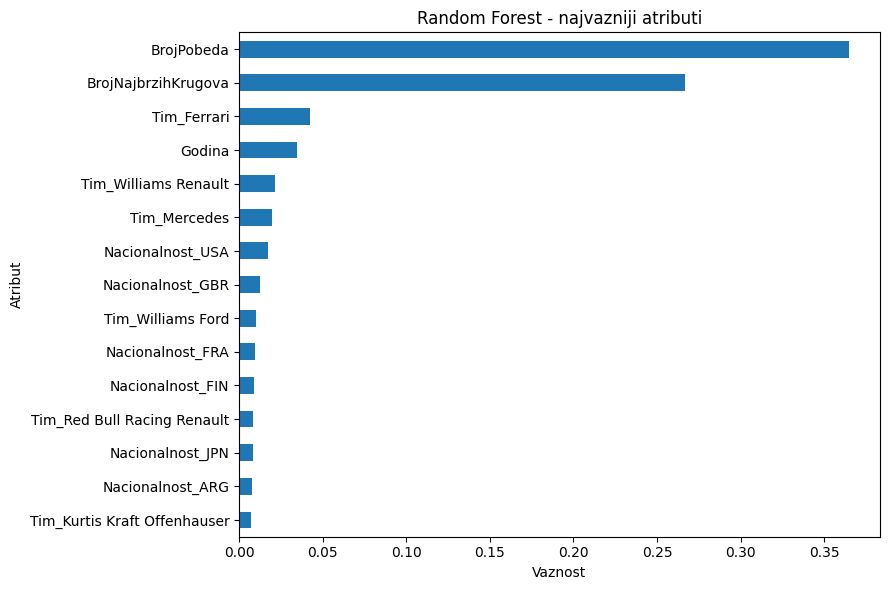

Slika sacuvana: c:\Users\Ilija\Desktop\F1_seminarski\python_deo\slike_python\06_vaznost_atributa_random_forest.png

Top 15 najvaznijih atributa Random Forest modela:
BrojPobeda                      0.365068
BrojNajbrzihKrugova             0.266750
Tim_Ferrari                     0.042199
Godina                          0.034895
Tim_Williams Renault            0.021504
Tim_Mercedes                    0.019752
Nacionalnost_USA                0.017559
Nacionalnost_GBR                0.012539
Tim_Williams Ford               0.009928
Nacionalnost_FRA                0.009635
Nacionalnost_FIN                0.009171
Tim_Red Bull Racing Renault     0.008281
Nacionalnost_JPN                0.008274
Nacionalnost_ARG                0.007847
Tim_Kurtis Kraft Offenhauser    0.007185
dtype: float64

Python deo je zavrsen. Slike su sacuvane u folderu: c:\Users\Ilija\Desktop\F1_seminarski\python_deo\slike_python


In [38]:
random_forest = modeli["Random Forest"]
random_forest.fit(X_train, y_train)

preprocesor = random_forest.named_steps["preprocesiranje"]
model_rf = random_forest.named_steps["model"]

nazivi_kategorickih = list(
    preprocesor
    .named_transformers_["kategoricki"]
    .get_feature_names_out(kategoricki_atributi)
)

svi_atributi = numericki_atributi + nazivi_kategorickih
vaznosti = pd.Series(model_rf.feature_importances_, index=svi_atributi)
top_vaznosti = vaznosti.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
top_vaznosti.sort_values().plot(kind="barh")
plt.title("Random Forest - najvazniji atributi")
plt.xlabel("Vaznost")
plt.ylabel("Atribut")
sacuvaj_sliku("06_vaznost_atributa_random_forest.png")

print("\nTop 15 najvaznijih atributa Random Forest modela:")
print(top_vaznosti)

print("\nPython deo je zavrsen. Slike su sacuvane u folderu:", FOLDER_SLIKE)